# 종합 실습 2 - 다중분류

**Digits 데이터셋**을 사용해 다중분류 실습을 진행한다.

Digits 데이터셋은 손글씨 숫자 이미지(0~9)를 담고 있으며, 딥러닝 기초에서 다중분류 예제로 자주 다뤄진다.

다만 이번 과정에서는 CNN이 아니라, 지금까지 배운 범위 안에서 **MLP 기반 분류기**로 접근한다.

- 입력: `8 x 8` 이미지 → 펼치면 64개의 feature
- 출력: 10개 클래스(0~9)
- 사용 개념
    - train / validation / test 분리
    - 입력 스케일링
    - DataLoader
    - MLP
    - CrossEntropyLoss
    - AdamW
    - StepLR
    - Early Stopping
    - confusion matrix
    - 예측 결과 해석

In [1]:
import copy
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.datasets import load_digits
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import TensorDataset, DataLoader

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

## 1. 데이터 확인

Digits 데이터셋은 각 이미지가 `8 x 8` grayscale 형태이다.  
픽셀값은 대략 `0 ~ 16` 범위를 가진다.

지금까지 CNN은 배우지 않았으므로, 이미지를 **1차원 벡터(64개 값)** 로 펼쳐서 MLP에 넣는다.

In [2]:
digits = load_digits()

X = digits.data          # 이미 펼쳐진 형태: (n_samples, 64)
y = digits.target        # 0~9 정답
images = digits.images   # 원래 이미지 형태: (n_samples, 8, 8)

print('X shape:', X.shape)
print('y shape:', y.shape)
print('images shape:', images.shape)
print('class labels:', np.unique(y))

X shape: (1797, 64)
y shape: (1797,)
images shape: (1797, 8, 8)
class labels: [0 1 2 3 4 5 6 7 8 9]


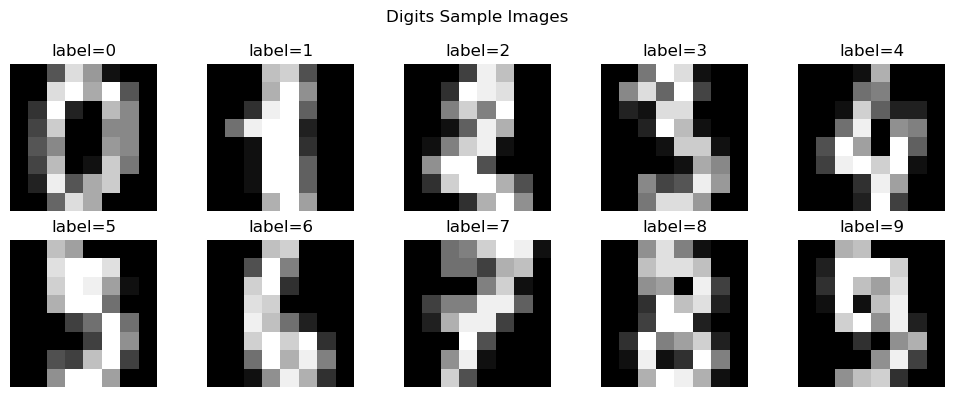

In [3]:
plt.figure(figsize=(10, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(images[i], cmap='gray')
    plt.title(f'label={y[i]}')
    plt.axis('off')

plt.suptitle('Digits Sample Images')
plt.tight_layout()
plt.show()

## 2. 데이터 분리와 정규화

다중분류 실습에서도
train / validation / test 분리를 명확히 해두는 습관이 중요하다.

입력 feature는 `StandardScaler`로 정규화한다.


In [4]:
# TODO 1. Digits 데이터를 train / validation / test로 나누고 정규화.
# - 첫 번째 분할: test_size=0.3, random_state=SEED, stratify=y
# - 두 번째 분할: validation / test로 반반 분할
# - StandardScaler는 train에만 fit
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=SEED, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=SEED, stratify=y_temp)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print('train:', X_train_scaled.shape, y_train.shape)
print('val  :', X_val_scaled.shape, y_val.shape)
print('test :', X_test_scaled.shape, y_test.shape)

train: (1257, 64) (1257,)
val  : (270, 64) (270,)
test : (270, 64) (270,)


## 3. Tensor / DataLoader 준비

`CrossEntropyLoss`를 사용할 때는 정답 y를 **클래스 번호 형태의 정수 tensor** 로 두는 것이 일반적이다.

In [5]:
# TODO 2. Tensor와 DataLoader를 준비해보자.
# - X는 float32
# - y는 torch.long
# - train_loader는 shuffle=True
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_val_tensor = torch.tensor(y_val, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

xb, yb = next(iter(train_loader))
print('mini batch X shape:', xb.shape)
print('mini batch y shape:', yb.shape)
print('y example:', yb[:10])

mini batch X shape: torch.Size([64, 64])
mini batch y shape: torch.Size([64])
y example: tensor([5, 1, 6, 3, 8, 5, 7, 9, 6, 7])


## 4. 다중분류용 MLP 모델

마지막 출력층 뉴런 수는 클래스 수와 같아야 하므로 10개로 둔다.

주의할 점:
`CrossEntropyLoss`를 쓸 때는 마지막에 softmax를 직접 넣지 않는다.  
이 손실 함수가 내부적으로 필요한 계산을 포함하고 있기 때문이다.


In [6]:
class DigitsMLP(nn.Module):
    def __init__(self, input_dim=64, num_classes=10, hidden_dims=[128, 64], dropout_rate=0.2):
        super().__init__()

        # TODO 3. 다중분류용 MLP를 완성
        # - hidden_dims를 순회하며 Linear -> ReLU -> Dropout을 쌓는다.
        # - 마지막 출력층 뉴런 수는 num_classes이다.
        layers = []
        prev_dim = input_dim

        for hidden_dim in hidden_dims:
            layers.append(nn.Linear(prev_dim, hidden_dim))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout_rate))
            prev_dim = hidden_dim

        layers.append(nn.Linear(prev_dim, num_classes))
        self.net = nn.Sequential(*layers)

        self._init_weights()

    def _init_weights(self):
        for module in self.modules():
            if isinstance(module, nn.Linear):
                nn.init.kaiming_uniform_(module.weight, nonlinearity='relu')
                nn.init.zeros_(module.bias)

    def forward(self, x):
        return self.net(x)

model = DigitsMLP()
print(model)

DigitsMLP(
  (net): Sequential(
    (0): Linear(in_features=64, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=64, out_features=10, bias=True)
  )
)


## 5. 학습/평가 함수

다중분류에서는 각 샘플에 대해 10개의 점수(logit)가 나온다.  
이 중 가장 큰 값의 위치가 예측 클래스가 된다.

즉,
- 학습 시 손실 계산: `CrossEntropyLoss`
- 예측 시 클래스 선택: `argmax(dim=1)`


In [7]:
def train_one_epoch_multiclass(model, loader, criterion, optimizer):
    model.train()

    running_loss = 0.0
    all_preds = []
    all_targets = []

    for X_batch, y_batch in loader:
        # TODO 4-1. 다중분류 학습 step을 완성
        # - zero_grad
        # - logits = model(...)
        # - loss 계산
        # - backward
        # - optimizer.step
        # - preds = logits.argmax(dim=1)
        optimizer.zero_grad()
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * X_batch.size(0)

        preds = logits.argmax(dim=1)
        all_preds.append(preds.detach())
        all_targets.append(y_batch.detach())

    epoch_loss = running_loss / len(loader.dataset)
    y_true = torch.cat(all_targets).numpy()
    y_pred = torch.cat(all_preds).numpy()
    epoch_acc = accuracy_score(y_true, y_pred)

    return epoch_loss, epoch_acc

def evaluate_multiclass_model(model, loader, criterion):
    model.eval()

    running_loss = 0.0
    all_logits = []
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            logits = model(X_batch)
            loss = criterion(logits, y_batch)

            running_loss += loss.item() * X_batch.size(0)

            # TODO 4-2. logits에서 예측 클래스를 구하는 코드를 완성
            preds = logits.argmax(dim=1)
            
            all_logits.append(logits)
            all_preds.append(preds)
            all_targets.append(y_batch)

    epoch_loss = running_loss / len(loader.dataset)
    y_true = torch.cat(all_targets).numpy()
    y_pred = torch.cat(all_preds).numpy()

    metrics = {
        'loss': epoch_loss,
        'accuracy': accuracy_score(y_true, y_pred)
    }
    return metrics, torch.cat(all_logits), y_true, y_pred


## 6. optimizer와 scheduler 설정

`StepLR`을 사용해보자.

- 처음에는 비교적 큰 learning rate로 시작
- 일정 epoch마다 learning rate를 줄임

이 방식은 규칙 기반 scheduler의 대표 예시이다.

In [8]:
# TODO 5. 손실 함수, optimizer, scheduler를 설정
# - 손실 함수: CrossEntropyLoss
# - optimizer: AdamW, lr=0.001, weight_decay=1e-4
# - scheduler: StepLR(step_size=15, gamma=0.5)
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=0.01, weight_decay=1e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=15, gamma=0.5)

print(optimizer)

AdamW (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: True
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    initial_lr: 0.01
    lr: 0.01
    maximize: False
    weight_decay: 0.0001
)


## 7. 전체 학습 루프 + Early Stopping

validation loss가 가장 낮은 모델을 저장하고,
오랫동안 개선이 없으면 중단한다.


In [9]:
num_epochs = 80
early_stopping_patience = 12

history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': [],
    'lr': []
}

best_val_loss = float('inf')
best_epoch = 0
best_state = copy.deepcopy(model.state_dict())
patience_counter = 0

for epoch in range(1, num_epochs + 1):
    train_loss, train_acc = train_one_epoch_multiclass(model, train_loader, criterion, optimizer)
    val_metrics, _, _, _ = evaluate_multiclass_model(model, val_loader, criterion)

    current_lr = optimizer.param_groups[0]['lr']

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_metrics['loss'])
    history['val_acc'].append(val_metrics['accuracy'])
    history['lr'].append(current_lr)

    # TODO 6-1. best model 갱신과 patience 카운트를 완성
    if val_metrics['loss'] < best_val_loss:
        best_val_loss = val_metrics['loss']
        best_epoch = epoch
        best_state = copy.deepcopy(model.state_dict())
        patience_counter = 0
    else:
        patience_counter += 1

    if epoch % 10 == 0 or epoch == 1:
        print(
            f'Epoch {epoch:03d} | '
            f'train_loss={train_loss:.4f} | train_acc={train_acc:.4f} | '
            f'val_loss={val_metrics["loss"]:.4f} | val_acc={val_metrics["accuracy"]:.4f} | '
            f'lr={current_lr:.6f}'
        )

    # TODO 6-2. epoch 단위 scheduler를 한 step 진행
    scheduler.step()

    if patience_counter >= early_stopping_patience:
        print(f'early stopping at epoch {epoch}')
        break

print('best epoch:', best_epoch)
print('best val loss:', round(best_val_loss, 4))

Epoch 001 | train_loss=1.0302 | train_acc=0.7041 | val_loss=0.2966 | val_acc=0.9407 | lr=0.010000
Epoch 010 | train_loss=0.0539 | train_acc=0.9777 | val_loss=0.3026 | val_acc=0.9667 | lr=0.010000
Epoch 020 | train_loss=0.0077 | train_acc=0.9984 | val_loss=0.2681 | val_acc=0.9667 | lr=0.005000
Epoch 030 | train_loss=0.0061 | train_acc=0.9976 | val_loss=0.2598 | val_acc=0.9704 | lr=0.005000
early stopping at epoch 33
best epoch: 21
best val loss: 0.2352


## 8. 학습 곡선 확인


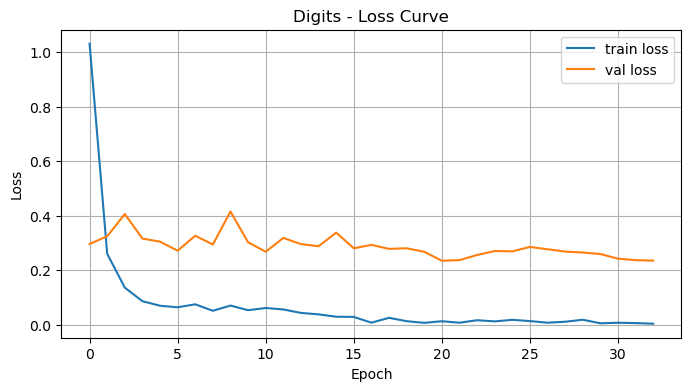

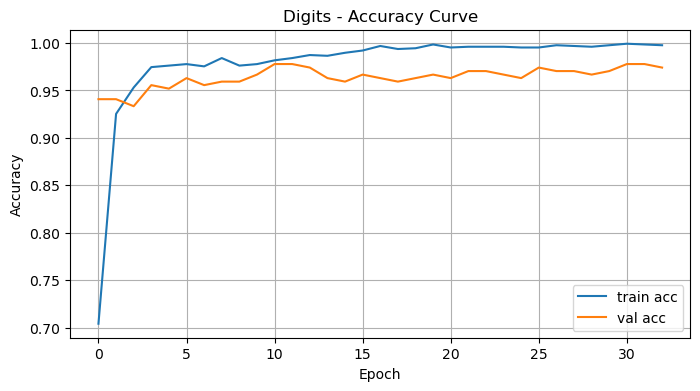

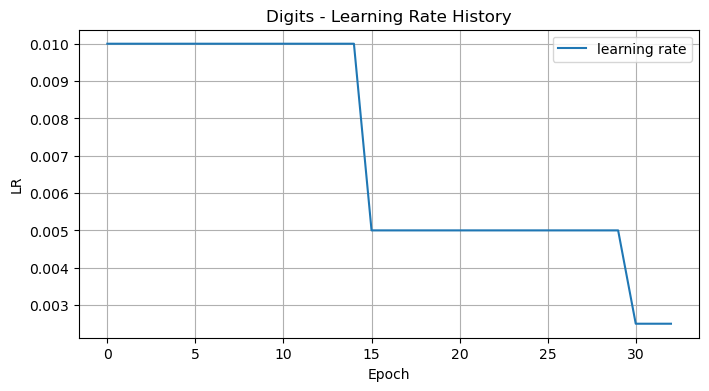

In [10]:
plt.figure(figsize=(8, 4))
plt.plot(history['train_loss'], label='train loss')
plt.plot(history['val_loss'], label='val loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Digits - Loss Curve')
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(history['train_acc'], label='train acc')
plt.plot(history['val_acc'], label='val acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Digits - Accuracy Curve')
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(history['lr'], label='learning rate')
plt.xlabel('Epoch')
plt.ylabel('LR')
plt.title('Digits - Learning Rate History')
plt.legend()
plt.grid()
plt.show()


## 9. best model 복원 후 test 평가


In [11]:
# TODO 7. best_state를 다시 불러오고 test 성능을 평가
model.load_state_dict(best_state)

test_metrics, test_logits, y_true_test, y_pred_test = evaluate_multiclass_model(model, test_loader, criterion)

print('test metrics')
for key, value in test_metrics.items():
    print(f'- {key}: {value:.4f}')

test metrics
- loss: 0.0993
- accuracy: 0.9815


## 10. confusion matrix와 분류 리포트

다중분류에서는 어떤 숫자끼리 자주 헷갈리는지 보는 것이 중요하다.  
예를 들어 3과 5, 8과 9처럼 비슷한 패턴의 숫자에서 오분류가 생길 수 있다.


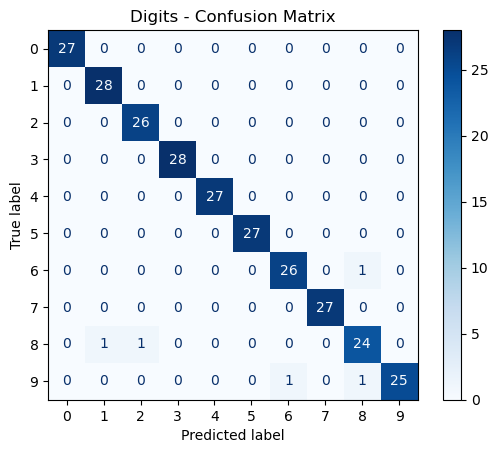

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        27
           1       0.97      1.00      0.98        28
           2       0.96      1.00      0.98        26
           3       1.00      1.00      1.00        28
           4       1.00      1.00      1.00        27
           5       1.00      1.00      1.00        27
           6       0.96      0.96      0.96        27
           7       1.00      1.00      1.00        27
           8       0.92      0.92      0.92        26
           9       1.00      0.93      0.96        27

    accuracy                           0.98       270
   macro avg       0.98      0.98      0.98       270
weighted avg       0.98      0.98      0.98       270



In [12]:
cm = confusion_matrix(y_true_test, y_pred_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.arange(10))
disp.plot(cmap='Blues')
plt.title('Digits - Confusion Matrix')
plt.show()

print(classification_report(y_true_test, y_pred_test))


## 11. softmax 확률까지 확인해보기

`CrossEntropyLoss` 학습에서는 마지막에 softmax를 직접 붙이지 않았지만,  
예측 결과를 해석할 때는 softmax를 적용해 클래스별 확률처럼 볼 수 있다.


In [13]:
model.eval()
with torch.no_grad():
    sample_X = X_test_tensor[:50]
    sample_logits = model(sample_X)

    # TODO 8. softmax 확률과 최종 예측 클래스를 구하는 코드를 완성
    sample_probs = torch.softmax(sample_logits, dim=1).numpy()
    sample_preds = sample_probs.argmax(axis=1)

for i in range(50):
    top_class = sample_preds[i]
    top_prob = sample_probs[i, top_class]
    print(
        f'index={i:2d} | true={y_test[i]} | pred={top_class} | '
        f'top_prob={top_prob:.4f}'
    )


index= 0 | true=6 | pred=6 | top_prob=1.0000
index= 1 | true=1 | pred=1 | top_prob=1.0000
index= 2 | true=8 | pred=8 | top_prob=0.9998
index= 3 | true=1 | pred=1 | top_prob=1.0000
index= 4 | true=3 | pred=3 | top_prob=1.0000
index= 5 | true=7 | pred=7 | top_prob=1.0000
index= 6 | true=6 | pred=6 | top_prob=1.0000
index= 7 | true=6 | pred=6 | top_prob=1.0000
index= 8 | true=9 | pred=9 | top_prob=0.6282
index= 9 | true=0 | pred=0 | top_prob=1.0000
index=10 | true=7 | pred=7 | top_prob=1.0000
index=11 | true=9 | pred=9 | top_prob=0.9707
index=12 | true=9 | pred=9 | top_prob=1.0000
index=13 | true=3 | pred=3 | top_prob=1.0000
index=14 | true=5 | pred=5 | top_prob=1.0000
index=15 | true=5 | pred=5 | top_prob=1.0000
index=16 | true=7 | pred=7 | top_prob=1.0000
index=17 | true=8 | pred=8 | top_prob=0.9949
index=18 | true=3 | pred=3 | top_prob=1.0000
index=19 | true=9 | pred=9 | top_prob=1.0000
index=20 | true=6 | pred=6 | top_prob=1.0000
index=21 | true=3 | pred=3 | top_prob=1.0000
index=22 |

## 12. 이미지와 예측 함께 보기


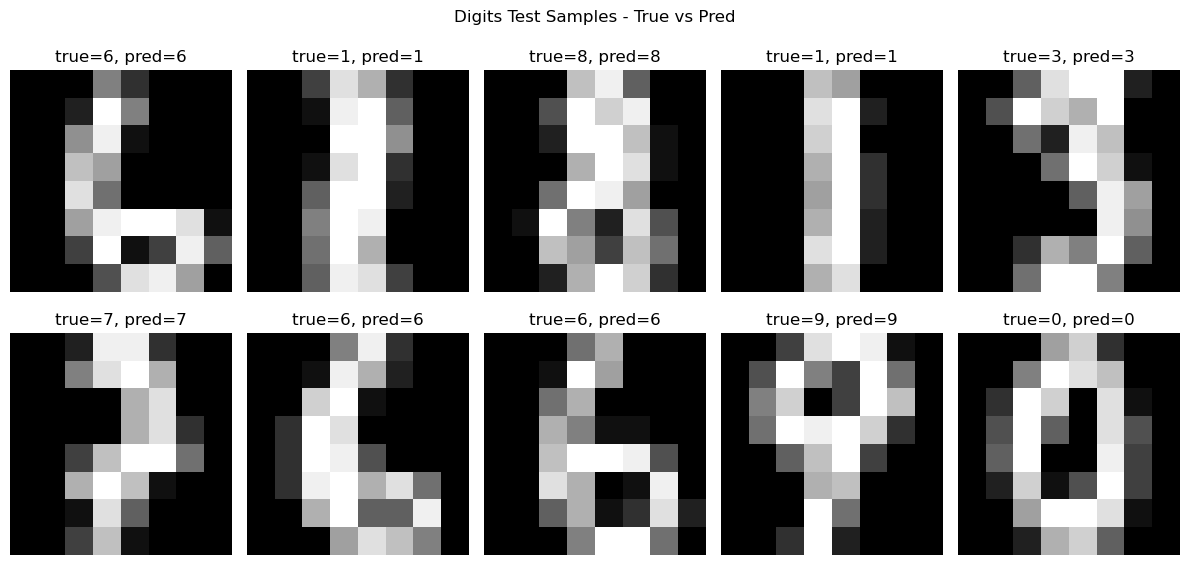

In [14]:
plt.figure(figsize=(12, 6))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_test[i].reshape(8, 8), cmap='gray')
    plt.title(f'true={y_test[i]}, pred={sample_preds[i]}')
    plt.axis('off')

plt.suptitle('Digits Test Samples - True vs Pred')
plt.tight_layout()
plt.show()
